In [1]:
from IPython.display import display, Image
import operator
from langgraph.graph import StateGraph, START, END
from typing import Annotated, Literal, List

from typing_extensions import TypedDict
from langgraph.types import Command, interrupt


In [9]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]
    

In [10]:
def node_a(state:State)->State:
    print('This is node[A]')
    return {}

def node_b(state:State)->State:
    print('This is node[B]')
    return State(nlist=['B'])

def node_c(state:State)->State:
    print('This is node[C]')
    return State(nlist=['C'])

def node_d(state:State)->State:
    print('This is node[D]')
    return State(nlist=['D'])

In [14]:
def conditional_edge(state:State) -> Literal["b","c", 'd']|type[END]:
    select = state['nlist'][-1]
    if select == 'b':
        return 'b'
    elif select == 'c':
        return 'c'
    elif select == 'q':
        return END
    else:
        return END
        

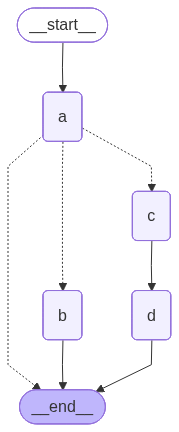

In [15]:

builder = StateGraph(State)
builder.add_node('a', node_a)
builder.add_node('b', node_b)
builder.add_node('c', node_c)
builder.add_node('d', node_d)

builder.add_edge(START, 'a')
builder.add_edge('b', END)
builder.add_edge('c', 'd')
builder.add_edge('d', END)
builder.add_conditional_edges(
    'a',
    conditional_edge,
    {
        'b':'b',
        'c':'c',
        END:END
    }
)


graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
user = input('b, c, or q to quit:')

input_state = State(
    nlist=[user]
)
graph.invoke(input_state)


This is node[A]
This is node[C]
This is node[D]


{'nlist': ['c', 'C', 'D']}

### 使用内置命令类型来实现条件分支


In [ ]:
'''
Command(
    update = State(nlist=[select])
    goto='c'
    )
'''

In [18]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {
    'configurable': {
        'thread_id':'1'
    }
}

In [19]:
graph = builder.compile(checkpointer=memory)

In [20]:
while True:
    user = input('b, c, or q to quit:')
    input_state = State(
        nlist=[user]
    )
    result = graph.invoke(input_state, config)
    print(result)
    if result['nlist'][-1] == 'q':
        print('quit')
        break

This is node[A]
This is node[B]
{'nlist': ['b', 'B']}
This is node[A]
This is node[C]
This is node[D]
{'nlist': ['b', 'B', 'c', 'C', 'D']}
This is node[A]
{'nlist': ['b', 'B', 'c', 'C', 'D', 'q']}
quit
